# curve fitting

In [21]:
import numpy as np

X = np.array([[2.5], [2.5],[ 5.0], [5.0], [10.0], [10.0],[20.0]], dtype=np.float32)
volume =  [10, 10, 10, 10,  90, 90, 90]
time =    [12.4, 12.7, 6.3, 6.1, 27.2, 27.4, 13.7]


In [14]:
(volume,time)

([10, 10, 10, 10, 90, 90, 90], [12.4, 12.7, 6.3, 6.1, 27.2, 27.4, 13.7])

In [38]:
flow  = [float(f"{a/b:.3g}")  for a,b in zip(volume , time ) ]
flow

[0.806, 0.787, 1.59, 1.64, 3.31, 3.28, 6.57]

In [39]:
y = np.array(flow, dtype=np.float32)
y

array([0.806, 0.787, 1.59 , 1.64 , 3.31 , 3.28 , 6.57 ], dtype=float32)

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [41]:

weight = float(f"{model.coef_[0]:.3g}")   # calibration facter
bias =  float(f"{model.intercept_:.3g}")   # drift
weight,bias


(0.331, -0.0279)

In [35]:
import matplotlib.pyplot as plt

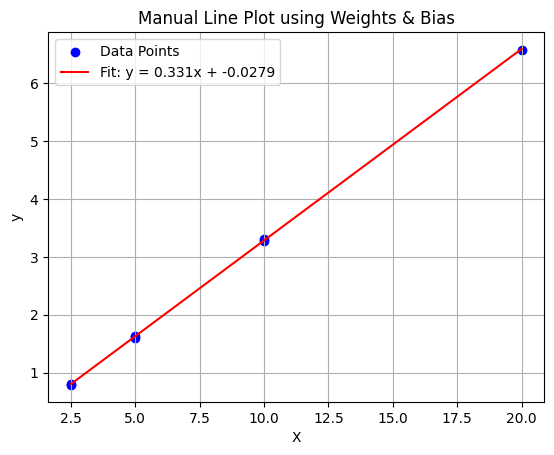

In [36]:
plt.scatter(X, y, color='blue', label='Points')
x_line = np.array([X.min(), X.max()])
y_line = (weight * x_line) + bias

plt.plot(x_line, y_line, color='red', label=f'Fit: y = {weight}x + {bias}')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Curve fitting')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)

print(f"Mean Squared Error: {mse:.3g}")


Mean Squared Error: 0.000408


#  piecewise linear interpolaation

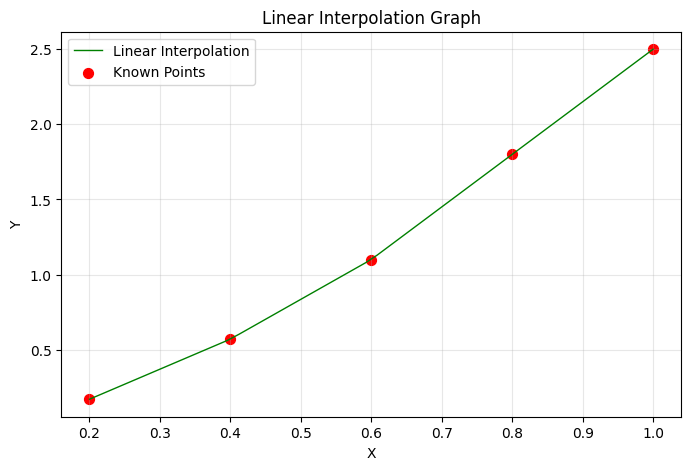

In [54]:


x_data = np.array([0.2,0.4,0.6,0.8,1], dtype=np.float32)
y_data = np.array([ 0.17, 0.57, 1.1, 1.8,2.5], dtype=np.float32)


x_extra = np.linspace(x_data.min(), x_data.max(), 50)

y_interp = np.interp(x_extra, x_data, y_data)

plt.figure(figsize=(8, 5))
plt.plot(x_extra, y_interp, color='green', label='Linear Interpolation', linewidth=1)
plt.scatter(x_data, y_data, color='red', s=50, label='Known Points')

plt.title("Linear Interpolation Graph")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [61]:
import numpy as np


x_test = np.array([0.3, 0.7], dtype=np.float32)
prediction = np.interp(x_test, x_data, y_data)

round_func = np.vectorize(lambda x: float(f"{x:.3g}"))

prediction_rounded = round_func(prediction)
print(prediction_rounded)



[0.37 1.45]
